# Hipótesis planteadas
*Hipótesis 1 — ERD en bandas Alpha/Mu y Beta*

Basado en la literatura de BCI, durante movimiento e imaginación de movimiento se espera una reducción de la potencia en las bandas alpha/mu (8-13 Hz) y beta (13-30 Hz) en los canales motores C3 y C4, fenómeno conocido como **Event-Related Desynchronization (ERD)**.

- **H₀:** No existe diferencia estadísticamente significativa en la potencia de las bandas alpha y beta entre las condiciones de tarea y reposo en C3 y C4
- **H₁:** La potencia de las bandas alpha y beta es significativamente diferente durante las tareas motoras comparada con el reposo, evidenciando ERD

*Hipótesis 2 — Lateralización hemisférica*

El control motor es contralateral: el hemisferio izquierdo controla la mano derecha (reflejado en C3) y el hemisferio derecho controla la mano izquierda (reflejado en C4).

- **H₀:** No existe diferencia en la potencia espectral entre los canales C3 y C4 durante movimiento real e imaginación de movimiento
- **H₁:** Existe diferencia  entre C3 y C4, evidenciando lateralización hemisférica en el control motor contralateral

*Hipótesis 3 — Movimiento real vs imaginado*

Los sistemas BCI se basan en que la imaginación de movimiento genera patrones cerebrales similares al movimiento real.

- **H₀:** No existe diferencia estadísticamente significativa en la potencia de las bandas alpha y beta entre movimiento real e imaginación de movimiento
- **H₁:** El movimiento real produce mayor ERD que el imaginado en las bandas alpha y beta en C3 y C4

**Prueba seleccionada:** Mann-Whitney U (no paramétrica)  
**Nivel de significancia:** α = 0.05

In [46]:
# Importar librerías

import mne                          # Para leer y procesar EEG
import numpy as np                  # Operaciones matemáticas vectorizadas
import pandas as pd                 # Para crear el DataFrame de resultados
import matplotlib.pyplot as plt     # Para graficar
import seaborn as sns               # Para gráficas estadísticas
from scipy import signal            # Para cálculo de PSD (Welch)
from scipy import stats             # Para pruebas estadísticas
from pathlib import Path            # Para manejar rutas de archivos

# Configuración general de gráficas
mne.set_log_level('WARNING')  # Evita que MNE imprima mensajes innecesarios
%matplotlib inline

In [47]:
# Rutas y parámetros globales

# Ruta donde están los datos descargados
RUTA_DATOS = Path("./datos_bci/files")

# 9 canales sobre zona sensoriomotora bilateral
# C3 → hemisferio izquierdo → mano derecha
# C4 → hemisferio derecho → mano izquierda
CANALES_INTERES = [
    'Fc3.', 'Fcz.', 'Fc4.',   # Corteza motora anterior
    'C3..', 'Cz..', 'C4..',   # Corteza motora primaria ⭐
    'Cp3.', 'Cpz.', 'Cp4.'    # Corteza somatosensorial
]

# Bandas de frecuencia del EEG
# Alpha/Mu y Beta son las más importantes para motor imagery (ERD/ERS)
BANDAS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),   # Banda Mu en contexto motor ⭐
    'beta':  (13, 30),  # Control motor ⭐
    'gamma': (30, 40)
}

# Frecuencia de muestreo del dataset (PhysioNet)
FS = 160  # Hz

# Filtros del pipeline de procesamiento
FREQ_MIN = 0.5   # Hz - elimina deriva de baja frecuencia
FREQ_MAX = 40.0  # Hz - elimina ruido de alta frecuencia
FREQ_NOTCH = 60  # Hz - elimina interferencia red eléctrica (USA)

# Mapeo de runs a condiciones experimentales
RUNS_CONDICIONES = {
    'R01': 'reposo_ojos_abiertos',
    'R02': 'reposo_ojos_cerrados',
    'R03': 'movimiento_real',
    'R04': 'imaginacion_movimiento',
    'R05': 'movimiento_real',
    'R06': 'imaginacion_movimiento',
    'R07': 'movimiento_real',
    'R08': 'imaginacion_movimiento',
    'R09': 'movimiento_real',
    'R10': 'imaginacion_movimiento',
    'R11': 'movimiento_real',
    'R12': 'imaginacion_movimiento',
    'R13': 'movimiento_real',
    'R14': 'imaginacion_movimiento',
}

# Verificación
print("Parámetros cargados correctamente")
print(f"   Ruta datos: {RUTA_DATOS}")
print(f"   Canales de interés: {CANALES_INTERES}")
print(f"   Bandas definidas: {list(BANDAS.keys())}")
print(f"   Frecuencia de muestreo: {FS} Hz")
print(f"   Filtro pasa banda: {FREQ_MIN} - {FREQ_MAX} Hz")
print(f"   Notch: {FREQ_NOTCH} Hz")

Parámetros cargados correctamente
   Ruta datos: datos_bci\files
   Canales de interés: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']
   Bandas definidas: ['delta', 'theta', 'alpha', 'beta', 'gamma']
   Frecuencia de muestreo: 160 Hz
   Filtro pasa banda: 0.5 - 40.0 Hz
   Notch: 60 Hz


In [48]:
# Verificar que los datos están disponibles

# Verificar que la ruta principal existe
if not RUTA_DATOS.exists():
    print("ERROR: La ruta de datos no existe. Verifica RUTA_DATOS")
else:
    print(f"Ruta encontrada: {RUTA_DATOS}")

# Contar sujetos disponibles
sujetos = sorted([s for s in RUTA_DATOS.iterdir() if s.is_dir()])
print(f"Sujetos encontrados: {len(sujetos)}")
print(f"   Primeros 3: {[s.name for s in sujetos[:3]]}")
print(f"   Últimos 3:  {[s.name for s in sujetos[-3:]]}")

# Verificar archivos del primer sujeto
# Confirma que cada sujeto tiene sus 14 runs (R01-R14)
archivos_s001 = sorted((RUTA_DATOS / "S001").glob("*.edf"))
print(f"\nArchivos EDF de S001: {len(archivos_s001)}")
for f in archivos_s001:
    print(f"   {f.name}")

Ruta encontrada: datos_bci\files
Sujetos encontrados: 109
   Primeros 3: ['S001', 'S002', 'S003']
   Últimos 3:  ['S107', 'S108', 'S109']

Archivos EDF de S001: 14
   S001R01.edf
   S001R02.edf
   S001R03.edf
   S001R04.edf
   S001R05.edf
   S001R06.edf
   S001R07.edf
   S001R08.edf
   S001R09.edf
   S001R10.edf
   S001R11.edf
   S001R12.edf
   S001R13.edf
   S001R14.edf


In [49]:
# Función de procesamiento de señal EEG

def procesar_eeg(ruta_archivo, mostrar_pasos=False):
    """
    Recibe un archivo EEG y aplica el flujo de procesamiento completo.
    
    Parámetros:
        ruta_archivo: ruta al archivo .edf
        mostrar_pasos: si True, grafica la señal en cada paso
    
    Retorna:
        raw: objeto MNE con la señal procesada
    """
    
    # PASO 1: Cargar el archivo
    # MNE lee directamente archivos EDF sin conversión previa
    raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
    
    if mostrar_pasos:
        print("Paso 1: Archivo cargado")
        print(f"   Canales: {len(raw.ch_names)}")
        print(f"   Duración: {raw.times[-1]:.1f} segundos")
        print(f"   Frecuencia de muestreo: {raw.info['sfreq']} Hz")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        data, times = raw[:5, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names[:5]):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 1: Señal cruda (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].grid(True)
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 1: Espectro crudo")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    # PASO 2: Seleccionar los 9 canales de la grilla sensoriomotora
    # Reduce la carga computacional y enfoca el análisis en zonas relevantes
    canales_disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]
    raw.pick(canales_disponibles)
    
    if mostrar_pasos:
        print(f"\nPaso 2: Canales seleccionados: {canales_disponibles}")
    
    # PASO 3: Filtro pasa banda (0.5-40 Hz) con método FIR
    # FIR preserva relaciones temporales entre canales (fase lineal)
    raw.filter(l_freq=FREQ_MIN, h_freq=FREQ_MAX, method='fir')
    
    if mostrar_pasos:
        print(f"\nPaso 3: Filtro pasa banda aplicado ({FREQ_MIN}-{FREQ_MAX} Hz)")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        data, times = raw[:, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 3: Después del filtro pasa banda (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=7)
        axes[0].grid(True)
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 3: Espectro después del filtro pasa banda")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    # PASO 4: Filtro Notch (60 Hz)
    # Aunque con FREQ_MAX=40Hz es casi redundante, se aplica
    # como buena práctica del pipeline estándar en BCI
    raw.notch_filter(freqs=FREQ_NOTCH)
    
    if mostrar_pasos:
        print(f"\nPaso 4: Filtro Notch aplicado ({FREQ_NOTCH} Hz)")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        data, times = raw[:, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 4: Después del filtro Notch (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=7)
        axes[0].grid(True)
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 4: Espectro después del filtro Notch")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    return raw

print("Función procesar_eeg() definida correctamente")

Función procesar_eeg() definida correctamente


In [50]:
# Exploración de datos antes de procesar

# Cargamos un archivo de prueba para explorar su contenido
# S001R03 → sujeto 1, run 3 → condición movimiento_manos
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_explorar = mne.io.read_raw_edf(archivo_prueba, preload=False)

# Ver información general del archivo
print("=== INFORMACIÓN GENERAL ===")
print(f"Canales totales: {len(raw_explorar.ch_names)}")
print(f"Duración: {raw_explorar.times[-1]:.1f} segundos")
print(f"Frecuencia de muestreo: {raw_explorar.info['sfreq']} Hz")
print(f"Muestras totales: {len(raw_explorar.times)}")

# Ver anotaciones/eventos del archivo
# T0 = reposo, T1 = mano izquierda, T2 = mano derecha
print("\n=== ANOTACIONES (EVENTOS) ===")
print(raw_explorar.annotations)

=== INFORMACIÓN GENERAL ===
Canales totales: 64
Duración: 125.0 segundos
Frecuencia de muestreo: 160.0 Hz
Muestras totales: 20000

=== ANOTACIONES (EVENTOS) ===
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


Paso 1: Archivo cargado
   Canales: 64
   Duración: 125.0 segundos
   Frecuencia de muestreo: 160.0 Hz


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:33: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


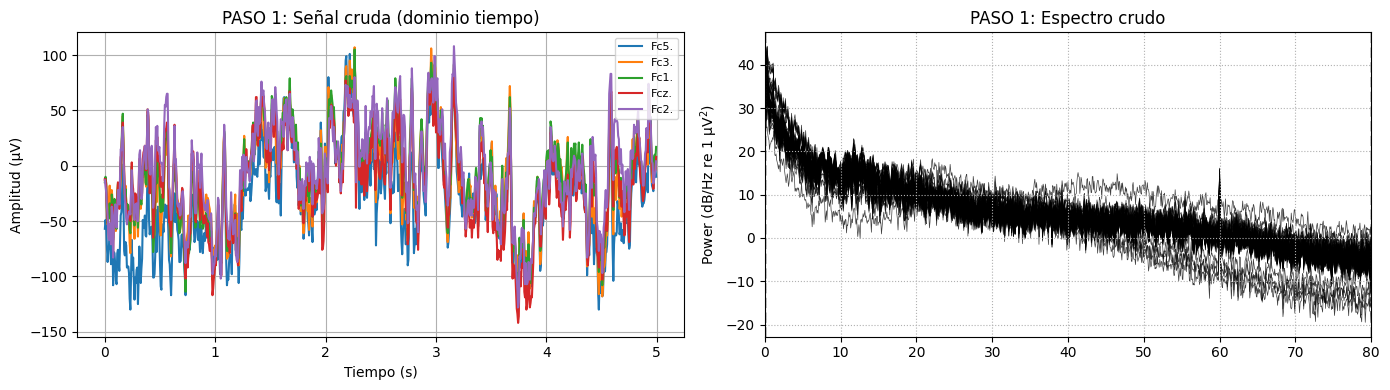


Paso 2: Canales seleccionados: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']

Paso 3: Filtro pasa banda aplicado (0.5-40.0 Hz)


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:62: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


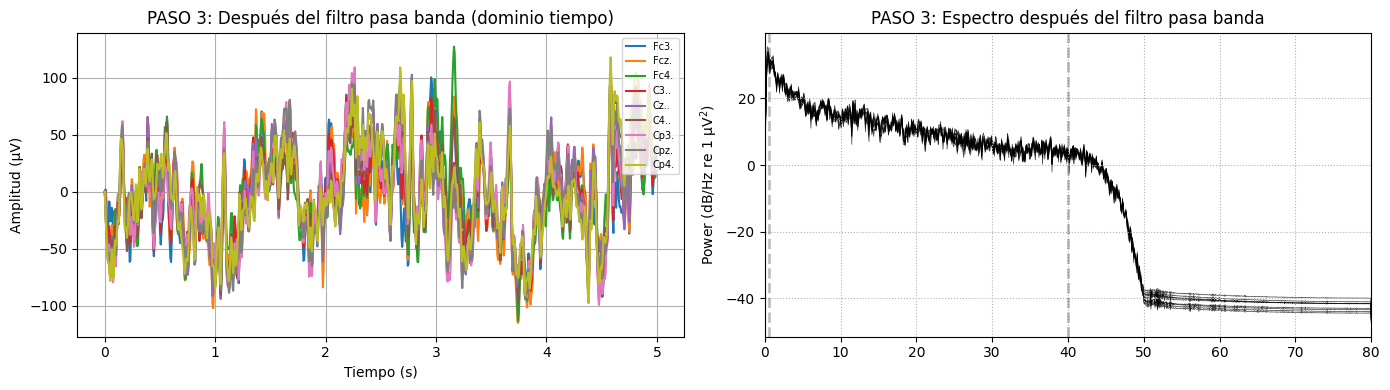


Paso 4: Filtro Notch aplicado (60 Hz)


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:84: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


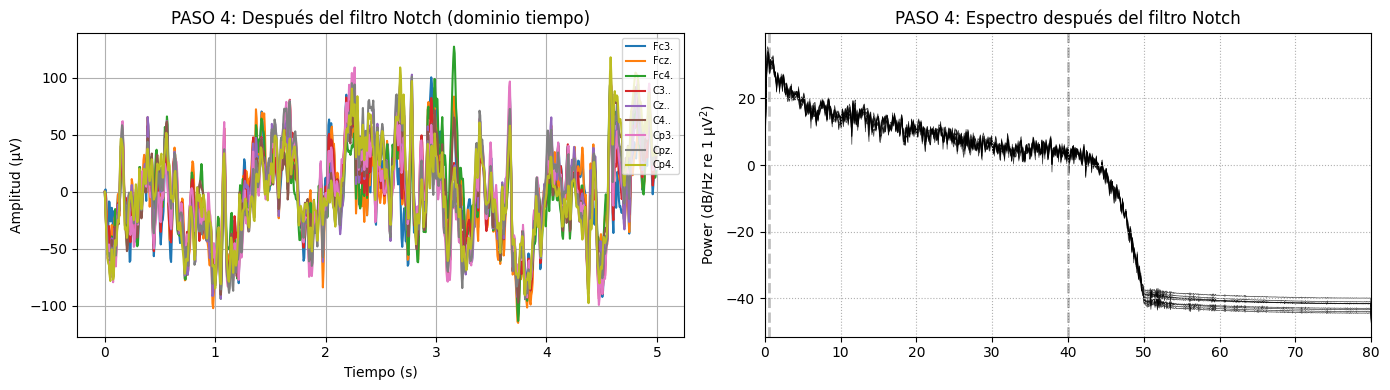

In [51]:
# Prueba de la función de procesamiento (para el informe)

# Se usa S001R03 (movimiento real de manos) como archivo representativo
# Es la condición con mayor actividad motora esperada
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"

# mostrar_pasos=True activa las gráficas de cada fase del procesamiento
# Esto permite ver visualmente el efecto de cada filtro aplicado
raw_prueba = procesar_eeg(archivo_prueba, mostrar_pasos=True)

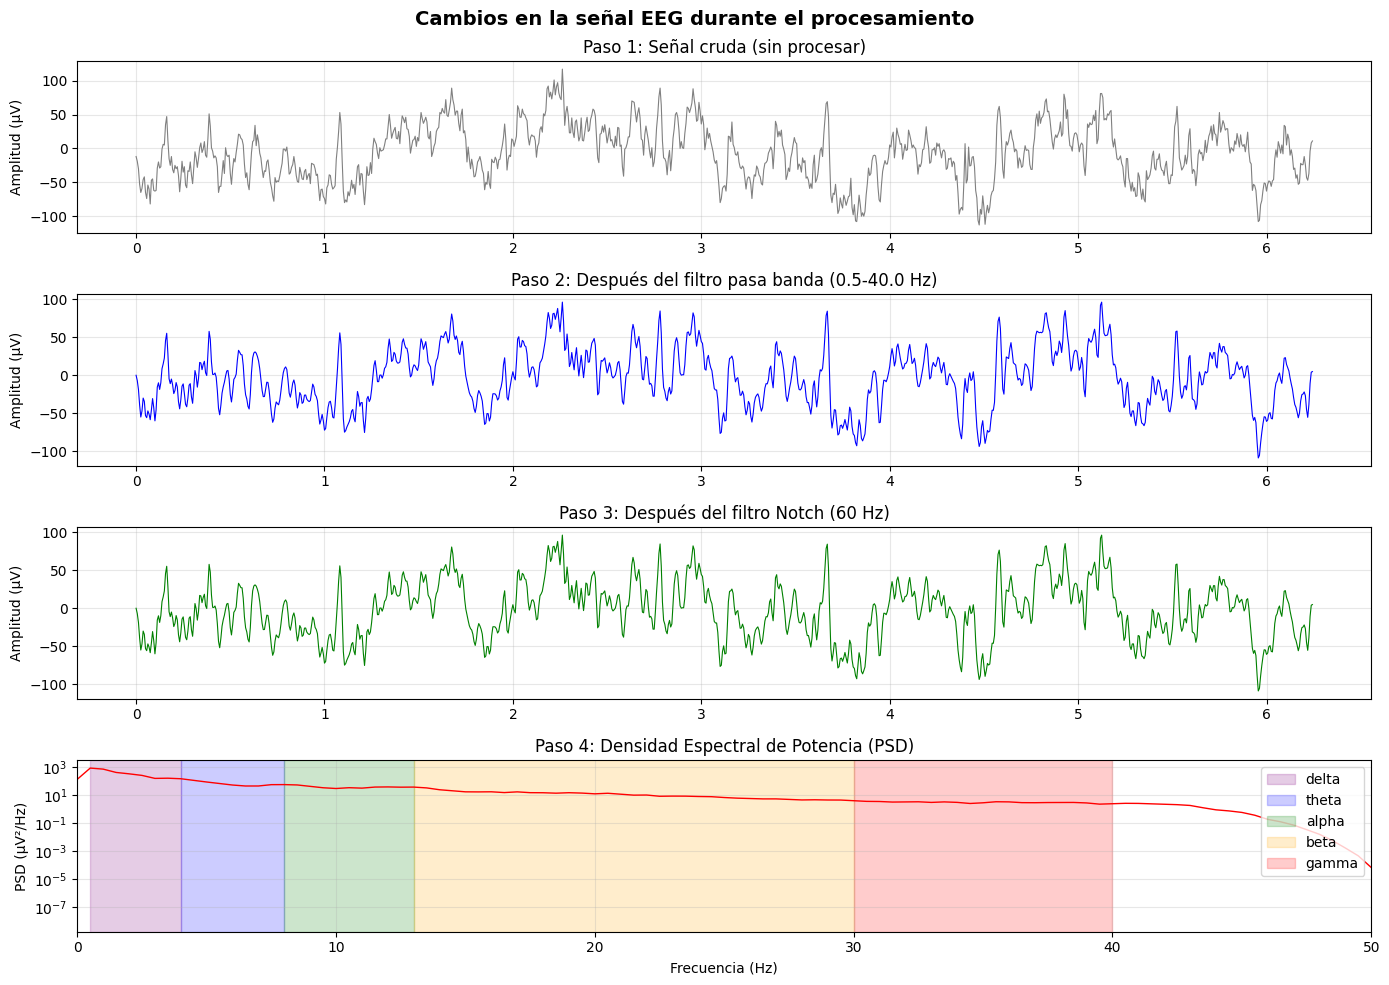

Figura guardada como 'procesamiento_señal.png'


In [52]:
# Visualizar cambios en el procesamiento

def visualizar_procesamiento(ruta_archivo):
    """
    Muestra cómo cambia la señal EEG en cada paso del procesamiento.
    Se usa canal C3 por ser el más relevante para motor imagery.
    """
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle('Cambios en la señal EEG durante el procesamiento', 
                 fontsize=14, fontweight='bold')
    
    # Paso 1: Señal cruda
    # Se carga sin filtrar para ver el estado original
    raw_cruda = mne.io.read_raw_edf(ruta_archivo, preload=True)
    raw_cruda.pick(['C3..'])
    datos_crudos = raw_cruda.get_data()[0]
    tiempos = raw_cruda.times
    
    axes[0].plot(tiempos[:1000], datos_crudos[:1000] * 1e6,
                 color='gray', linewidth=0.8)
    axes[0].set_title('Paso 1: Señal cruda (sin procesar)')
    axes[0].set_ylabel('Amplitud (µV)')
    axes[0].grid(True, alpha=0.3)
    
    # Paso 2: Filtro pasa banda (0.5-40 Hz)
    # Elimina deriva de baja frecuencia y ruido de alta frecuencia
    raw_filtrada = mne.io.read_raw_edf(ruta_archivo, preload=True)
    raw_filtrada.pick(['C3..'])
    raw_filtrada.filter(l_freq=FREQ_MIN, h_freq=FREQ_MAX)
    datos_filtrados = raw_filtrada.get_data()[0]
    
    axes[1].plot(tiempos[:1000], datos_filtrados[:1000] * 1e6,
                 color='blue', linewidth=0.8)
    axes[1].set_title(f'Paso 2: Después del filtro pasa banda ({FREQ_MIN}-{FREQ_MAX} Hz)')
    axes[1].set_ylabel('Amplitud (µV)')
    axes[1].grid(True, alpha=0.3)
    
    # Paso 3: Filtro Notch (60 Hz)
    # Elimina interferencia de red eléctrica
    # Visualmente similar al paso 2 porque el pasa banda ya cortó 40Hz
    raw_notch = mne.io.read_raw_edf(ruta_archivo, preload=True)
    raw_notch.pick(['C3..'])
    raw_notch.filter(l_freq=FREQ_MIN, h_freq=FREQ_MAX)
    raw_notch.notch_filter(freqs=FREQ_NOTCH)
    datos_notch = raw_notch.get_data()[0]
    
    axes[2].plot(tiempos[:1000], datos_notch[:1000] * 1e6,
                 color='green', linewidth=0.8)
    axes[2].set_title(f'Paso 3: Después del filtro Notch ({FREQ_NOTCH} Hz)')
    axes[2].set_ylabel('Amplitud (µV)')
    axes[2].grid(True, alpha=0.3)
    
    # Paso 4: PSD con método de Welch
    # Ventana de 2 segundos → resolución espectral de 0.5 Hz
    # Permite distinguir claramente las bandas de interés
    freqs_psd, psd = signal.welch(
        datos_notch, 
        fs=FS, 
        nperseg=int(FS * 2)
    )
    
    axes[3].semilogy(freqs_psd, psd * 1e12, color='red', linewidth=1)
    axes[3].set_title('Paso 4: Densidad Espectral de Potencia (PSD)')
    axes[3].set_xlabel('Frecuencia (Hz)')
    axes[3].set_ylabel('PSD (µV²/Hz)')
    axes[3].set_xlim([0, 50])
    axes[3].grid(True, alpha=0.3)
    
    # Marcar las bandas con colores para identificarlas visualmente
    colores_bandas = {
        'delta': 'purple', 'theta': 'blue', 
        'alpha': 'green', 'beta': 'orange', 'gamma': 'red'
    }
    for banda, (f_min, f_max) in BANDAS.items():
        axes[3].axvspan(f_min, f_max, alpha=0.2, 
                        color=colores_bandas[banda], label=banda)
    axes[3].legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('procesamiento_señal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura guardada como 'procesamiento_señal.png'")

# Aplicar sobre archivo representativo (S001R03 = movimiento real de manos)
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
visualizar_procesamiento(archivo_prueba)

In [53]:
# Explorar anotaciones y segmentos

# Cargamos un archivo procesado para explorar su estructura de eventos
# S001R03 → movimiento real de manos
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Ver todas las anotaciones del archivo
# Cada anotación indica: etiqueta, inicio y duración del segmento
print("=== ANOTACIONES DEL ARCHIVO S001R03 ===")
for ann in raw_test.annotations:
    print(f"   Etiqueta: {ann['description']} | Inicio: {ann['onset']:.1f}s | Duración: {ann['duration']:.1f}s")

# Contar segmentos por tipo
# T0=reposo, T1=mano izquierda, T2=mano derecha
etiquetas = [ann['description'] for ann in raw_test.annotations]
print(f"\n=== RESUMEN ===")
print(f"   T0 (reposo):       {etiquetas.count('T0')} segmentos")
print(f"   T1 (mano izq):     {etiquetas.count('T1')} segmentos")
print(f"   T2 (mano der):     {etiquetas.count('T2')} segmentos")
print(f"   Duración típica:   {raw_test.annotations[0]['duration']:.1f} segundos")

=== ANOTACIONES DEL ARCHIVO S001R03 ===
   Etiqueta: T0 | Inicio: 0.0s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 4.2s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 8.3s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 12.5s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 16.6s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 20.8s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 24.9s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 29.1s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 33.2s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 37.4s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 41.5s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 45.7s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 49.8s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 54.0s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 58.1s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 62.3s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 66.4s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 70.6s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 74.7s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 78.9s 

In [54]:
# Función para calcular PSD por bandas

def calcular_psd_por_bandas(raw):
    """
    Calcula la densidad espectral de potencia (PSD) para cada
    canal y cada banda de frecuencia definida en BANDAS.
    
    Parámetros:
        raw: objeto MNE con la señal ya procesada
    
    Retorna:
        resultado: diccionario con potencia promedio por banda y canal
                   Ejemplo: {'alpha_C3..': 0.23, 'beta_C4..': 0.15, ...}
    """
    
    # Extraer datos como array numpy: forma (n_canales, n_muestras)
    datos = raw.get_data()
    fs = raw.info['sfreq']  # frecuencia de muestreo
    
    resultado = {}
    
    for idx, canal in enumerate(raw.ch_names):
        
        señal_canal = datos[idx, :]
        
        # Método de Welch: divide la señal en segmentos de 2 segundos,
        # calcula FFT de cada uno y promedia → estimación más robusta
        # Resolución espectral = fs/nperseg = 160/320 = 0.5 Hz
        freqs, psd = signal.welch(
            señal_canal,
            fs=fs,
            nperseg=int(fs * 2)  # ventana de 2 segundos
        )
        
        # Extraer potencia promedio en cada banda de frecuencia
        for nombre_banda, (f_min, f_max) in BANDAS.items():
            
            # Índices de frecuencias dentro de la banda
            # Ej: alpha (8-13 Hz) → todos los índices donde 8 ≤ freq ≤ 13
            indices_banda = np.where(
                (freqs >= f_min) & (freqs <= f_max)
            )[0]
            
            # Potencia promedio en la banda
            potencia = np.mean(psd[indices_banda])
            
            # Clave: "banda_canal" → ej: "alpha_C3.."
            clave = f"{nombre_banda}_{canal}"
            resultado[clave] = potencia
    
    return resultado

print("Función calcular_psd_por_bandas() definida correctamente")

Función calcular_psd_por_bandas() definida correctamente


In [55]:
# Prueba de la función calcular_psd_por_bandas

# Aplicar sobre archivo de prueba
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Calcular PSD sobre toda la señal
resultado_prueba = calcular_psd_por_bandas(raw_test)

# Mostrar resultados en V²/Hz
print("=== RESULTADO PSD POR BANDAS Y CANAL ===")
for clave, potencia in resultado_prueba.items():
    print(f"   {clave}: {potencia:.2e} V²/Hz")

# Verificar que se obtienen todas las combinaciones esperadas
# 5 bandas × 9 canales = 45 combinaciones
n_esperado = len(BANDAS) * len(CANALES_INTERES)
print(f"\n=== VERIFICACIÓN ===")
print(f"   Combinaciones esperadas (bandas x canales): {n_esperado}")
print(f"   Combinaciones obtenidas: {len(resultado_prueba)}")

=== RESULTADO PSD POR BANDAS Y CANAL ===
   delta_Fc3.: 4.56e-10 V²/Hz
   theta_Fc3.: 7.76e-11 V²/Hz
   alpha_Fc3.: 3.78e-11 V²/Hz
   beta_Fc3.: 1.32e-11 V²/Hz
   gamma_Fc3.: 2.99e-12 V²/Hz
   delta_Fcz.: 4.35e-10 V²/Hz
   theta_Fcz.: 8.80e-11 V²/Hz
   alpha_Fcz.: 3.74e-11 V²/Hz
   beta_Fcz.: 1.29e-11 V²/Hz
   gamma_Fcz.: 3.15e-12 V²/Hz
   delta_Fc4.: 3.54e-10 V²/Hz
   theta_Fc4.: 6.14e-11 V²/Hz
   alpha_Fc4.: 2.93e-11 V²/Hz
   beta_Fc4.: 1.02e-11 V²/Hz
   gamma_Fc4.: 2.50e-12 V²/Hz
   delta_C3..: 3.80e-10 V²/Hz
   theta_C3..: 7.41e-11 V²/Hz
   alpha_C3..: 3.89e-11 V²/Hz
   beta_C3..: 1.21e-11 V²/Hz
   gamma_C3..: 3.04e-12 V²/Hz
   delta_Cz..: 3.84e-10 V²/Hz
   theta_Cz..: 8.21e-11 V²/Hz
   alpha_Cz..: 3.78e-11 V²/Hz
   beta_Cz..: 1.17e-11 V²/Hz
   gamma_Cz..: 3.30e-12 V²/Hz
   delta_C4..: 2.93e-10 V²/Hz
   theta_C4..: 5.60e-11 V²/Hz
   alpha_C4..: 2.91e-11 V²/Hz
   beta_C4..: 9.52e-12 V²/Hz
   gamma_C4..: 2.54e-12 V²/Hz
   delta_Cp3.: 3.69e-10 V²/Hz
   theta_Cp3.: 7.30e-11 V²/Hz
   al

In [56]:
# Verificación visual de la PSD por bandas

# Mostrar potencias en µV²/Hz (unidad estándar en EEG)
# Conversión: V²/Hz × 1e12 = µV²/Hz
print("=== POTENCIA POR BANDA (en µV²/Hz) ===\n")

for banda in BANDAS.keys():
    print(f"--- {banda.upper()} ---")
    for canal in CANALES_INTERES:
        clave = f"{banda}_{canal}"
        # Convertir de V²/Hz a µV²/Hz
        potencia_uv = resultado_prueba[clave] * 1e12
        print(f"   {canal}: {potencia_uv:.4f} µV²/Hz")
    print()

# Se verifica que Delta > Theta > Alpha > Beta > Gamma
# confirmando que la señal es EEG real y el procesamiento es correcto

=== POTENCIA POR BANDA (en µV²/Hz) ===

--- DELTA ---
   Fc3.: 456.2533 µV²/Hz
   Fcz.: 434.7547 µV²/Hz
   Fc4.: 354.4238 µV²/Hz
   C3..: 379.6878 µV²/Hz
   Cz..: 383.9974 µV²/Hz
   C4..: 293.0944 µV²/Hz
   Cp3.: 368.9739 µV²/Hz
   Cpz.: 387.1058 µV²/Hz
   Cp4.: 320.3040 µV²/Hz

--- THETA ---
   Fc3.: 77.5603 µV²/Hz
   Fcz.: 88.0078 µV²/Hz
   Fc4.: 61.4017 µV²/Hz
   C3..: 74.0846 µV²/Hz
   Cz..: 82.1415 µV²/Hz
   C4..: 56.0042 µV²/Hz
   Cp3.: 72.9780 µV²/Hz
   Cpz.: 74.2424 µV²/Hz
   Cp4.: 59.4481 µV²/Hz

--- ALPHA ---
   Fc3.: 37.7941 µV²/Hz
   Fcz.: 37.4326 µV²/Hz
   Fc4.: 29.3452 µV²/Hz
   C3..: 38.9486 µV²/Hz
   Cz..: 37.7547 µV²/Hz
   C4..: 29.1187 µV²/Hz
   Cp3.: 42.4917 µV²/Hz
   Cpz.: 40.7007 µV²/Hz
   Cp4.: 35.0045 µV²/Hz

--- BETA ---
   Fc3.: 13.1562 µV²/Hz
   Fcz.: 12.8672 µV²/Hz
   Fc4.: 10.2322 µV²/Hz
   C3..: 12.0870 µV²/Hz
   Cz..: 11.6753 µV²/Hz
   C4..: 9.5175 µV²/Hz
   Cp3.: 11.9294 µV²/Hz
   Cpz.: 11.4764 µV²/Hz
   Cp4.: 10.3746 µV²/Hz

--- GAMMA ---
   Fc3.: 2.9869

In [57]:
# Función para identificar condición del archivo

import re

def identificar_condicion(nombre_archivo):
    """
    Dado el nombre de un archivo, retorna la condición experimental.
    
    Parámetros:
        nombre_archivo: string con el nombre del archivo
                        Ejemplo: "S001R03.edf"
    
    Retorna:
        condicion: string con la condición
    """
    
    nombre = str(nombre_archivo)
    
    # Extraer número de run usando expresión regular
    # Patrón "RXX": S001R03.edf → run 3
    match = re.search(r'R(\d+)', nombre)
    
    if match is None:
        return "desconocido"
    
    run = int(match.group(1))
    
    # Cada condición tiene 3 runs para mayor robustez estadística
    if run in [1, 2]:
        return "reposo"
    elif run in [3, 7, 11]:
        return "movimiento_manos"
    elif run in [4, 8, 12]:
        return "imaginacion_manos"
    elif run in [5, 9, 13]:
        return "movimiento_punos"
    elif run in [6, 10, 14]:
        return "imaginacion_punos"
    else:
        return "desconocido"

print("Función identificar_condicion() definida correctamente")
print("\n=== PRUEBA ===")
for archivo in ["S001R01.edf", "S001R03.edf", "S001R04.edf", 
                "S001R05.edf", "S001R06.edf"]:
    print(f"   {archivo} → {identificar_condicion(archivo)}")

Función identificar_condicion() definida correctamente

=== PRUEBA ===
   S001R01.edf → reposo
   S001R03.edf → movimiento_manos
   S001R04.edf → imaginacion_manos
   S001R05.edf → movimiento_punos
   S001R06.edf → imaginacion_punos


In [58]:
# Función para calcular PSD por segmentos (T0, T1, T2)

def calcular_psd_por_segmentos(raw):
    """
    Extrae los segmentos T0, T1, T2 del archivo y calcula
    la PSD promedio para cada tipo de segmento.
    
    Parámetros:
        raw: objeto MNE con la señal ya procesada
    
    Retorna:
        resultado: diccionario con potencia promedio por 
                   etiqueta, banda y canal
                   Ejemplo: {'T0_alpha_C3..': 0.23, 
                              'T1_beta_C4..': 0.15, ...}
    """
    
    fs = raw.info['sfreq']
    resultado = {}
    
    # Agrupar segmentos por etiqueta
    # T0=reposo, T1=mano izquierda, T2=mano derecha
    segmentos_por_etiqueta = {'T0': [], 'T1': [], 'T2': []}
    
    for ann in raw.annotations:
        etiqueta = ann['description']
        if etiqueta not in segmentos_por_etiqueta:
            continue
        
        # Convertir tiempos a índices de muestras
        inicio = int(ann['onset'] * fs)
        fin = inicio + int(ann['duration'] * fs)
        
        # Extraer segmento: forma (n_canales, n_muestras_segmento)
        datos_segmento = raw.get_data()[:, inicio:fin]
        segmentos_por_etiqueta[etiqueta].append(datos_segmento)
    
    # Calcular PSD promedio para cada etiqueta
    for etiqueta, segmentos in segmentos_por_etiqueta.items():
        
        if len(segmentos) == 0:
            continue
        
        for idx, canal in enumerate(raw.ch_names):
            
            psds_canal = []
            
            for segmento in segmentos:
                señal = segmento[idx, :]
                # Welch con ventana de 2s → resolución 0.5 Hz
                freqs, psd = signal.welch(
                    señal,
                    fs=fs,
                    nperseg=int(fs * 2)
                )
                psds_canal.append(psd)
            
            # Promediar PSDs del mismo tipo → estimación más robusta
            psd_promedio = np.mean(psds_canal, axis=0)
            
            # Extraer potencia promedio en cada banda
            for nombre_banda, (f_min, f_max) in BANDAS.items():
                indices_banda = np.where(
                    (freqs >= f_min) & (freqs <= f_max)
                )[0]
                potencia = np.mean(psd_promedio[indices_banda])
                
                # Formato clave: "T0_alpha_C3.."
                clave = f"{etiqueta}_{nombre_banda}_{canal}"
                resultado[clave] = potencia
    
    return resultado

print("Función calcular_psd_por_segmentos() definida correctamente")

Función calcular_psd_por_segmentos() definida correctamente


In [59]:
# CELDA 8b: Prueba de calcular_psd_por_segmentos

# Aplicar sobre archivo de prueba
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Calcular PSD separada por segmentos T0, T1, T2
resultado_segmentos = calcular_psd_por_segmentos(raw_test)

# Mostrar solo C3, Cz, C4 para no saturar la salida
# Estos son los canales más relevantes para motor imagery
print("=== PSD POR SEGMENTOS (en µV²/Hz) ===\n")
for etiqueta in ['T0', 'T1', 'T2']:
    print(f"--- {etiqueta} ---")
    for banda in BANDAS.keys():
        for canal in ['C3..', 'Cz..', 'C4..']:
            clave = f"{etiqueta}_{banda}_{canal}"
            if clave in resultado_segmentos:
                potencia_uv = resultado_segmentos[clave] * 1e12
                print(f"   {banda}_{canal}: {potencia_uv:.4f} µV²/Hz")
    print()

# Verificar 135 combinaciones: 3 etiquetas × 5 bandas × 9 canales
n_esperado = len(['T0','T1','T2']) * len(BANDAS) * len(CANALES_INTERES)
print(f"=== VERIFICACIÓN ===")
print(f"   Combinaciones esperadas (etiquetas x bandas x canales): {n_esperado}")
print(f"   Combinaciones obtenidas: {len(resultado_segmentos)}")

=== PSD POR SEGMENTOS (en µV²/Hz) ===

--- T0 ---
   delta_C3..: 319.5002 µV²/Hz
   delta_Cz..: 353.4208 µV²/Hz
   delta_C4..: 249.4330 µV²/Hz
   theta_C3..: 66.0405 µV²/Hz
   theta_Cz..: 74.8227 µV²/Hz
   theta_C4..: 53.2134 µV²/Hz
   alpha_C3..: 39.9974 µV²/Hz
   alpha_Cz..: 38.0680 µV²/Hz
   alpha_C4..: 32.2472 µV²/Hz
   beta_C3..: 12.2339 µV²/Hz
   beta_Cz..: 11.4479 µV²/Hz
   beta_C4..: 10.3455 µV²/Hz
   gamma_C3..: 2.9654 µV²/Hz
   gamma_Cz..: 3.1124 µV²/Hz
   gamma_C4..: 2.6697 µV²/Hz

--- T1 ---
   delta_C3..: 411.7781 µV²/Hz
   delta_Cz..: 385.9264 µV²/Hz
   delta_C4..: 296.4670 µV²/Hz
   theta_C3..: 74.4361 µV²/Hz
   theta_Cz..: 69.8934 µV²/Hz
   theta_C4..: 47.6130 µV²/Hz
   alpha_C3..: 35.7002 µV²/Hz
   alpha_Cz..: 35.0893 µV²/Hz
   alpha_C4..: 24.4312 µV²/Hz
   beta_C3..: 10.7814 µV²/Hz
   beta_Cz..: 11.1253 µV²/Hz
   beta_C4..: 8.1261 µV²/Hz
   gamma_C3..: 2.8138 µV²/Hz
   gamma_Cz..: 3.4188 µV²/Hz
   gamma_C4..: 2.4448 µV²/Hz

--- T2 ---
   delta_C3..: 240.0623 µV²/Hz
  

In [60]:
# Rutina principal - procesar todos los archivos

def procesar_todos_los_archivos(ruta_datos, max_sujetos=None):
    """
    Recorre todos los archivos EEG del dataset, los procesa
    y guarda los resultados en un DataFrame.
    
    Parámetros:
        ruta_datos: Path a la carpeta con los datos
        max_sujetos: número máximo de sujetos a procesar
                     (None = procesar todos)
    
    Retorna:
        df: DataFrame con todos los resultados
    """
    
    # Buscar todas las carpetas de sujetos ordenadas
    sujetos = sorted([s for s in ruta_datos.iterdir() if s.is_dir()])
    
    if max_sujetos is not None:
        sujetos = sujetos[:max_sujetos]
    
    print(f"Sujetos a procesar: {len(sujetos)}")
    
    filas = []
    
    for i, carpeta_sujeto in enumerate(sujetos):
        
        sujeto = carpeta_sujeto.name
        print(f"\nSujeto {i+1}/{len(sujetos)}: {sujeto}")
        
        # Buscar todos los archivos .edf del sujeto
        archivos = sorted(carpeta_sujeto.glob("*.edf"))
        
        for archivo in archivos:
            
            condicion = identificar_condicion(archivo.name)
            print(f"   {archivo.name} → {condicion}")
            
            try:
                # Paso 1: procesar la señal EEG
                raw = procesar_eeg(archivo, mostrar_pasos=False)
                
                # Paso 2: calcular PSD por segmentos T0, T1, T2
                # Esto separa reposo de tarea dentro de cada archivo
                potencias = calcular_psd_por_segmentos(raw)
                
                # Paso 3: construir fila del DataFrame
                fila = {
                    'sujeto': sujeto,
                    'archivo': archivo.name,
                    'condicion': condicion,
                }
                fila.update(potencias)
                filas.append(fila)
                
            except Exception as e:
                # Si un archivo falla se registra y continúa
                # para no interrumpir el procesamiento completo
                print(f"   Error: {e}")
                continue
    
    df = pd.DataFrame(filas)
    
    print(f"\nProcesamiento completado!")
    print(f"   Total registros: {len(df)}")
    print(f"   Columnas: {len(df.columns)}")
    
    return df

print("Función procesar_todos_los_archivos() definida correctamente")

Función procesar_todos_los_archivos() definida correctamente


In [61]:
# Prueba con 2 sujetos

# Prueba con 2 sujetos antes de correr el dataset completo
# Verifica estructura del DataFrame y que no hay errores
df_prueba = procesar_todos_los_archivos(RUTA_DATOS, max_sujetos=2)

# Verificar estructura: 28 filas (2 sujetos × 14 archivos)
print("\n=== PRIMERAS FILAS ===")
print(df_prueba[['sujeto', 'archivo', 'condicion']].to_string())

# Verificar columnas: 138 = 3 identificadores + 135 valores PSD
print(f"\n=== COLUMNAS ({len(df_prueba.columns)}) ===")
print(list(df_prueba.columns))

Sujetos a procesar: 2

Sujeto 1/2: S001
   S001R01.edf → reposo
   S001R02.edf → reposo
   S001R03.edf → movimiento_manos
   S001R04.edf → imaginacion_manos
   S001R05.edf → movimiento_punos
   S001R06.edf → imaginacion_punos
   S001R07.edf → movimiento_manos
   S001R08.edf → imaginacion_manos
   S001R09.edf → movimiento_punos
   S001R10.edf → imaginacion_punos
   S001R11.edf → movimiento_manos
   S001R12.edf → imaginacion_manos
   S001R13.edf → movimiento_punos
   S001R14.edf → imaginacion_punos

Sujeto 2/2: S002
   S002R01.edf → reposo
   S002R02.edf → reposo
   S002R03.edf → movimiento_manos
   S002R04.edf → imaginacion_manos
   S002R05.edf → movimiento_punos
   S002R06.edf → imaginacion_punos
   S002R07.edf → movimiento_manos
   S002R08.edf → imaginacion_manos
   S002R09.edf → movimiento_punos
   S002R10.edf → imaginacion_punos
   S002R11.edf → movimiento_manos
   S002R12.edf → imaginacion_manos
   S002R13.edf → movimiento_punos
   S002R14.edf → imaginacion_punos

Procesamiento com

In [62]:
# Ejecutar procesamiento completo

# Procesar todos los 109 sujetos
# Este proceso tarda aproximadamente 40 minutos
# No cerrar el notebook mientras corre
df_resultados = procesar_todos_los_archivos(RUTA_DATOS, max_sujetos=None)

# Guardar resultados en CSV para no reprocesar en futuras ejecuciones
# El CSV ocupa ~4 MB con los 1526 registros y 138 columnas
df_resultados.to_csv("resultados_bci.csv", index=False)
print("\nResultados guardados en resultados_bci.csv")

# Vista previa del DataFrame
df_resultados.head()

Sujetos a procesar: 109

Sujeto 1/109: S001
   S001R01.edf → reposo
   S001R02.edf → reposo
   S001R03.edf → movimiento_manos
   S001R04.edf → imaginacion_manos
   S001R05.edf → movimiento_punos
   S001R06.edf → imaginacion_punos
   S001R07.edf → movimiento_manos
   S001R08.edf → imaginacion_manos
   S001R09.edf → movimiento_punos
   S001R10.edf → imaginacion_punos
   S001R11.edf → movimiento_manos
   S001R12.edf → imaginacion_manos
   S001R13.edf → movimiento_punos
   S001R14.edf → imaginacion_punos

Sujeto 2/109: S002
   S002R01.edf → reposo
   S002R02.edf → reposo
   S002R03.edf → movimiento_manos
   S002R04.edf → imaginacion_manos
   S002R05.edf → movimiento_punos
   S002R06.edf → imaginacion_punos
   S002R07.edf → movimiento_manos
   S002R08.edf → imaginacion_manos
   S002R09.edf → movimiento_punos
   S002R10.edf → imaginacion_punos
   S002R11.edf → movimiento_manos
   S002R12.edf → imaginacion_manos
   S002R13.edf → movimiento_punos
   S002R14.edf → imaginacion_punos

Sujeto 3/10

c:\Users\Valentina Garcia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\Valentina Garcia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\Valentina Garcia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


   S088R04.edf → imaginacion_manos
   S088R05.edf → movimiento_punos
   S088R06.edf → imaginacion_punos


c:\Users\Valentina Garcia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\Valentina Garcia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 176, using nperseg = 176
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


   S088R07.edf → movimiento_manos
   S088R08.edf → imaginacion_manos
   S088R09.edf → movimiento_punos


...

C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)


   S100R11.edf → movimiento_manos
   S100R12.edf → imaginacion_manos
   S100R13.edf → movimiento_punos
   S100R14.edf → imaginacion_punos


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\2284404546.py:17: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(ruta_archivo, preload=True)



Sujeto 101/109: S101
   S101R01.edf → reposo
   S101R02.edf → reposo
   S101R03.edf → movimiento_manos
   S101R04.edf → imaginacion_manos
   S101R05.edf → movimiento_punos
   S101R06.edf → imaginacion_punos
   S101R07.edf → movimiento_manos
   S101R08.edf → imaginacion_manos
   S101R09.edf → movimiento_punos
   S101R10.edf → imaginacion_punos
   S101R11.edf → movimiento_manos
   S101R12.edf → imaginacion_manos
   S101R13.edf → movimiento_punos
   S101R14.edf → imaginacion_punos

Sujeto 102/109: S102
   S102R01.edf → reposo
   S102R02.edf → reposo
   S102R03.edf → movimiento_manos
   S102R04.edf → imaginacion_manos
   S102R05.edf → movimiento_punos
   S102R06.edf → imaginacion_punos
   S102R07.edf → movimiento_manos
   S102R08.edf → imaginacion_manos
   S102R09.edf → movimiento_punos
   S102R10.edf → imaginacion_punos
   S102R11.edf → movimiento_manos
   S102R12.edf → imaginacion_manos
   S102R13.edf → movimiento_punos
   S102R14.edf → imaginacion_punos

Sujeto 103/109: S103
   S103R01

,sujeto,archivo,condicion,T0_delta_Fc3.,T0_theta_Fc3.,T0_alpha_Fc3.,T0_beta_Fc3.,T0_gamma_Fc3.,T0_delta_Fcz.,T0_theta_Fcz.,...,T2_delta_Cpz.,T2_theta_Cpz.,T2_alpha_Cpz.,T2_beta_Cpz.,T2_gamma_Cpz.,T2_delta_Cp4.,T2_theta_Cp4.,T2_alpha_Cp4.,T2_beta_Cp4.,T2_gamma_Cp4.
0,S001,S001R01.edf,reposo,4.026466e-10,7.497265e-11,4.095015e-11,1.147376e-11,2.779680e-12,4.162234e-10,8.656348e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S001,S001R02.edf,reposo,2.189626e-10,7.313727e-11,1.022140e-10,1.264895e-11,3.269664e-12,2.536478e-10,8.378791e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S001,S001R03.edf,movimiento_manos,3.441590e-10,7.202640e-11,4.150189e-11,1.384364e-11,2.899547e-12,3.510940e-10,8.573717e-11,...,2.805838e-10,6.332240e-11,3.653315e-11,1.141407e-11,2.795347e-12,2.443449e-10,4.825545e-11,2.863269e-11,9.826086e-12,2.445425e-12
3,S001,S001R04.edf,imaginacion_manos,3.176287e-10,7.179276e-11,4.202691e-11,1.470024e-11,3.624427e-12,3.728856e-10,8.462642e-11,...,5.041027e-10,6.178579e-11,3.056820e-11,9.502496e-12,2.875602e-12,3.958019e-10,4.904488e-11,3.034523e-11,8.669281e-12,2.488869e-12
4,S001,S001R05.edf,movimiento_punos,3.259745e-10,6.951898e-11,3.338497e-11,1.384755e-11,3.503524e-12,3.603560e-10,8.058663e-11,...,4.714527e-10,8.221290e-11,3.494558e-11,1.252510e-11,5.126071e-12,3.485910e-10,6.368631e-11,3.031759e-11,9.796539e-12,3.635633e-12


In [63]:
# Cargar resultados y preparar datos para análisis

# Cargar CSV guardado en el procesamiento anterior
# Esto evita reprocesar los ~40 minutos de cálculo
df = pd.read_csv("resultados_bci.csv")

print(f"Datos cargados correctamente")
print(f"   Registros: {len(df)}")
print(f"   Columnas: {len(df.columns)}")

# Verificar distribución de condiciones
# Se esperan 327 registros por condición de tarea y 218 de reposo
print(f"\n=== CONDICIONES ===")
print(df['condicion'].value_counts())

# Verificar total de sujetos
print(f"\n=== SUJETOS ===")
print(f"   Total: {df['sujeto'].nunique()}")

# Vista previa del DataFrame
print(f"\n=== PRIMERAS FILAS ===")
df.head()

Datos cargados correctamente
   Registros: 1526
   Columnas: 138

=== CONDICIONES ===
condicion
movimiento_manos     327
movimiento_punos     327
imaginacion_manos    327
imaginacion_punos    327
reposo               218
Name: count, dtype: int64

=== SUJETOS ===
   Total: 109

=== PRIMERAS FILAS ===


,sujeto,archivo,condicion,T0_delta_Fc3.,T0_theta_Fc3.,T0_alpha_Fc3.,T0_beta_Fc3.,T0_gamma_Fc3.,T0_delta_Fcz.,T0_theta_Fcz.,...,T2_delta_Cpz.,T2_theta_Cpz.,T2_alpha_Cpz.,T2_beta_Cpz.,T2_gamma_Cpz.,T2_delta_Cp4.,T2_theta_Cp4.,T2_alpha_Cp4.,T2_beta_Cp4.,T2_gamma_Cp4.
0,S001,S001R01.edf,reposo,4.026466e-10,7.497265e-11,4.095015e-11,1.147376e-11,2.779680e-12,4.162234e-10,8.656348e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S001,S001R02.edf,reposo,2.189626e-10,7.313727e-11,1.022140e-10,1.264895e-11,3.269664e-12,2.536478e-10,8.378791e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S001,S001R03.edf,movimiento_manos,3.441590e-10,7.202640e-11,4.150189e-11,1.384364e-11,2.899547e-12,3.510940e-10,8.573717e-11,...,2.805838e-10,6.332240e-11,3.653315e-11,1.141407e-11,2.795347e-12,2.443449e-10,4.825545e-11,2.863269e-11,9.826086e-12,2.445425e-12
3,S001,S001R04.edf,imaginacion_manos,3.176287e-10,7.179276e-11,4.202691e-11,1.470024e-11,3.624427e-12,3.728856e-10,8.462642e-11,...,5.041027e-10,6.178579e-11,3.056820e-11,9.502496e-12,2.875602e-12,3.958019e-10,4.904488e-11,3.034523e-11,8.669281e-12,2.488869e-12
4,S001,S001R05.edf,movimiento_punos,3.259745e-10,6.951898e-11,3.338497e-11,1.384755e-11,3.503524e-12,3.603560e-10,8.058663e-11,...,4.714527e-10,8.221290e-11,3.494558e-11,1.252510e-11,5.126071e-12,3.485910e-10,6.368631e-11,3.031759e-11,9.796539e-12,3.635633e-12


In [64]:
# CELDA 12: Preparar datos para análisis

# Las columnas originales tienen formato: T0_banda_canal, T1_banda_canal, T2_banda_canal
# Se crean columnas nuevas para facilitar comparaciones entre condiciones:
#   - tarea_banda_canal  → promedio T1 y T2 (actividad durante la tarea)
#   - reposo_banda_canal → T0 (actividad durante el reposo)

for banda in BANDAS.keys():
    for canal in CANALES_INTERES:
        col_t0 = f'T0_{banda}_{canal}'
        col_t1 = f'T1_{banda}_{canal}'
        col_t2 = f'T2_{banda}_{canal}'
        
        # Promedio T1 y T2: representa actividad general durante la tarea
        # independiente de qué mano se usó
        df[f'tarea_{banda}_{canal}'] = df[[col_t1, col_t2]].mean(axis=1)
        
        # T0: actividad durante el reposo (línea base)
        df[f'reposo_{banda}_{canal}'] = df[col_t0]

print("Datos preparados para análisis")
print(f"   Columnas totales: {len(df.columns)}")
print(f"\nEjemplo columnas nuevas:")
nuevas = [c for c in df.columns if c.startswith('tarea_')][:5]
print(nuevas)

Datos preparados para análisis
   Columnas totales: 228

Ejemplo columnas nuevas:
['tarea_delta_Fc3.', 'tarea_delta_Fcz.', 'tarea_delta_Fc4.', 'tarea_delta_C3..', 'tarea_delta_Cz..']


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\4206569994.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\4206569994.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\4206569994.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\4206569994.py:53

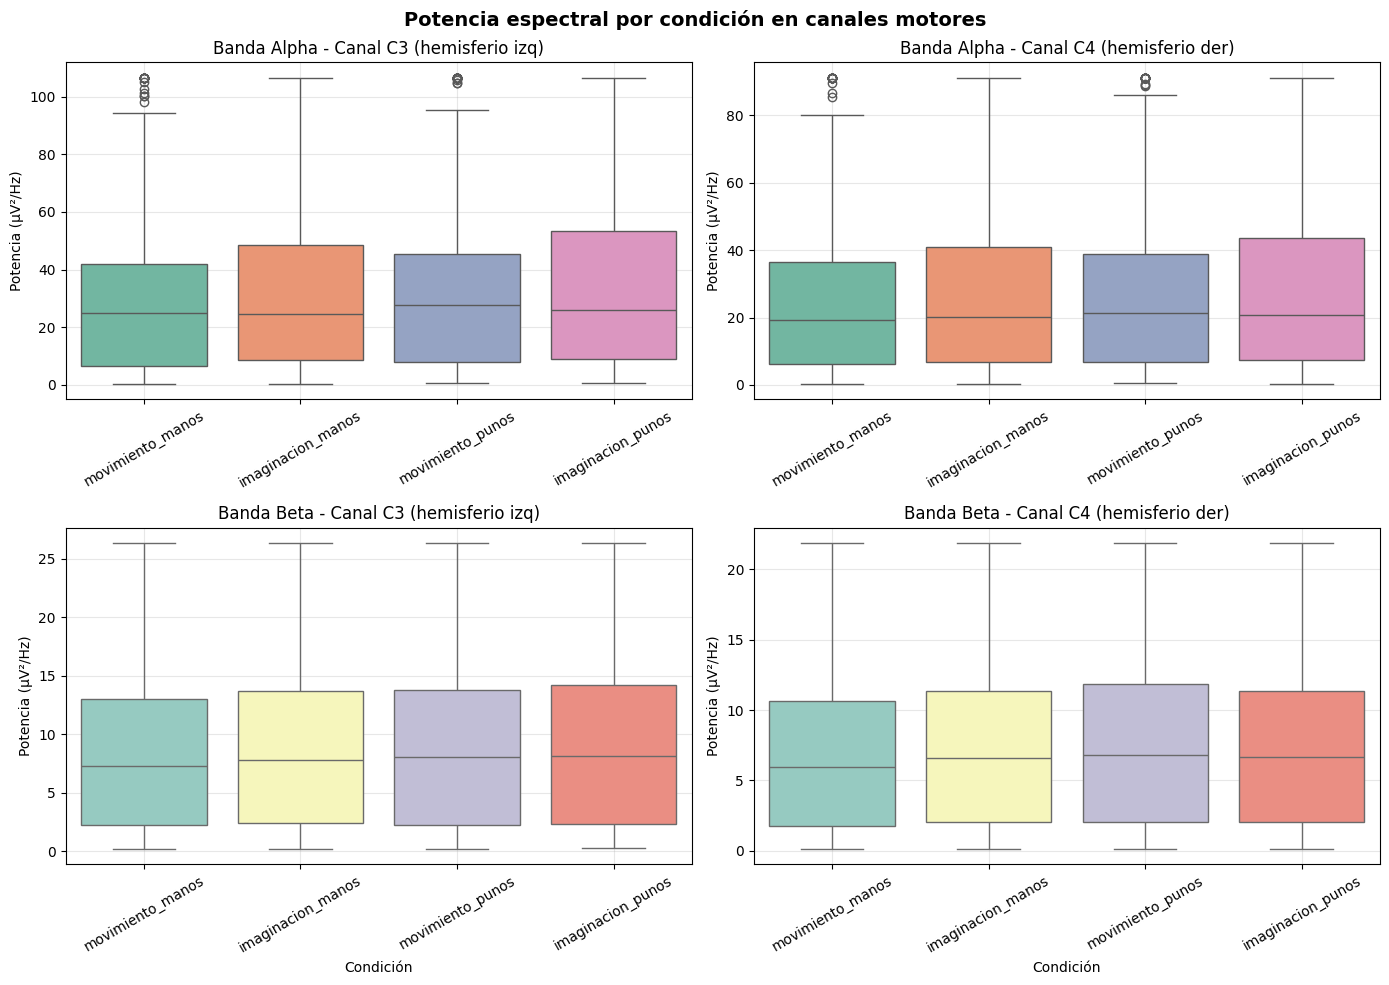

Figura guardada como 'boxplot_alpha_beta.png'


In [65]:
# Estadística descriptiva - Boxplots Alpha y Beta

# Filtrar las 4 condiciones de tarea (excluir reposo)
condiciones_interes = ['movimiento_manos', 'imaginacion_manos', 
                       'movimiento_punos', 'imaginacion_punos']
df_analisis = df[df['condicion'].isin(condiciones_interes)].copy()

# Convertir V²/Hz → µV²/Hz (unidad estándar en EEG)
for col in df_analisis.columns:
    if col.startswith('tarea_') or col.startswith('T'):
        df_analisis[col] = df_analisis[col] * 1e12

# Eliminar outliers extremos (percentil 95)
# Justificación: reducir efecto de artefactos en la visualización
# sin eliminar datos del análisis estadístico
for col in df_analisis.columns:
    if col.startswith('tarea_'):
        p95 = df_analisis[col].quantile(0.95)
        df_analisis[col] = df_analisis[col].clip(upper=p95)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Potencia espectral por condición en canales motores', 
             fontsize=14, fontweight='bold')

# Alpha C3 — hemisferio izquierdo → mano derecha
sns.boxplot(data=df_analisis, x='condicion', 
            y='tarea_alpha_C3..', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Banda Alpha - Canal C3 (hemisferio izq)')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Potencia (µV²/Hz)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(True, alpha=0.3)

# Alpha C4 — hemisferio derecho → mano izquierda
sns.boxplot(data=df_analisis, x='condicion', 
            y='tarea_alpha_C4..', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Banda Alpha - Canal C4 (hemisferio der)')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Potencia (µV²/Hz)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].grid(True, alpha=0.3)

# Beta C3
sns.boxplot(data=df_analisis, x='condicion', 
            y='tarea_beta_C3..', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Banda Beta - Canal C3 (hemisferio izq)')
axes[1,0].set_xlabel('Condición')
axes[1,0].set_ylabel('Potencia (µV²/Hz)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(True, alpha=0.3)

# Beta C4
sns.boxplot(data=df_analisis, x='condicion', 
            y='tarea_beta_C4..', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Banda Beta - Canal C4 (hemisferio der)')
axes[1,1].set_xlabel('Condición')
axes[1,1].set_ylabel('Potencia (µV²/Hz)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_alpha_beta.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'boxplot_alpha_beta.png'")

C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\3313055175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\3313055175.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\3313055175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\3313055175.py:19

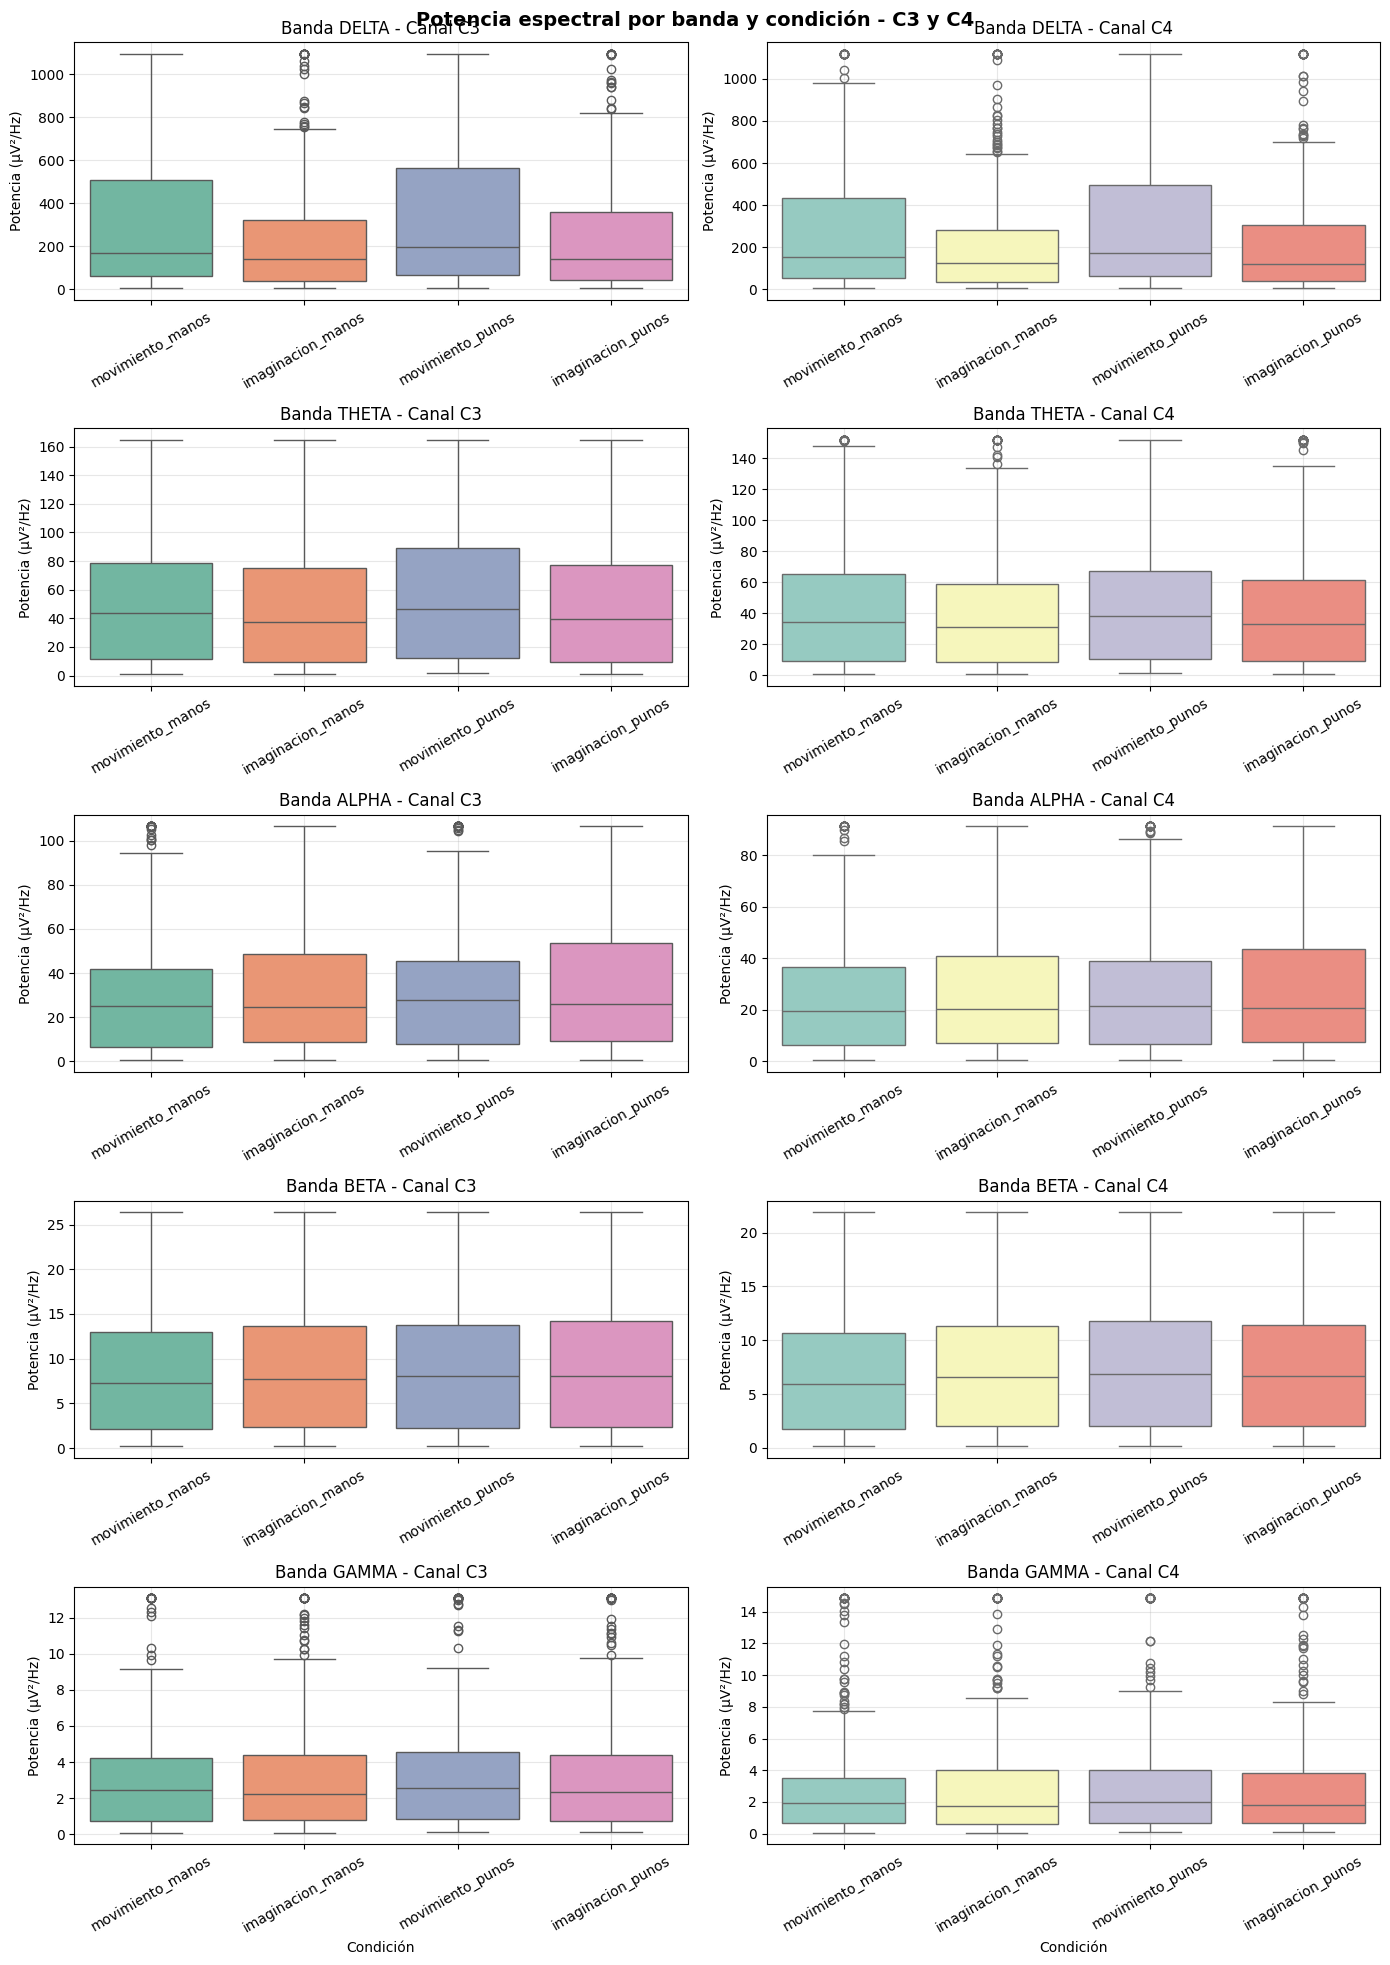

Figura guardada como 'boxplot_todas_bandas.png'


In [66]:
# Estadística descriptiva - Todas las bandas en C3 y C4

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle('Potencia espectral por banda y condición - C3 y C4', 
             fontsize=14, fontweight='bold')

for idx, banda in enumerate(BANDAS.keys()):
    
    # Canal C3
    sns.boxplot(data=df_analisis, x='condicion',
                y=f'tarea_{banda}_C3..', ax=axes[idx,0], palette='Set2')
    axes[idx,0].set_title(f'Banda {banda.upper()} - Canal C3')
    axes[idx,0].set_xlabel('')
    axes[idx,0].set_ylabel('Potencia (µV²/Hz)')
    axes[idx,0].tick_params(axis='x', rotation=30)
    axes[idx,0].grid(True, alpha=0.3)
    
    # Canal C4
    sns.boxplot(data=df_analisis, x='condicion',
                y=f'tarea_{banda}_C4..', ax=axes[idx,1], palette='Set3')
    axes[idx,1].set_title(f'Banda {banda.upper()} - Canal C4')
    axes[idx,1].set_xlabel('')
    axes[idx,1].set_ylabel('Potencia (µV²/Hz)')
    axes[idx,1].tick_params(axis='x', rotation=30)
    axes[idx,1].grid(True, alpha=0.3)

axes[-1,0].set_xlabel('Condición')
axes[-1,1].set_xlabel('Condición')

plt.tight_layout()
plt.savefig('boxplot_todas_bandas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'boxplot_todas_bandas.png'")

C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\1114781322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\1114781322.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\1114781322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_analisis, x='condicion',
C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_9468\11147813

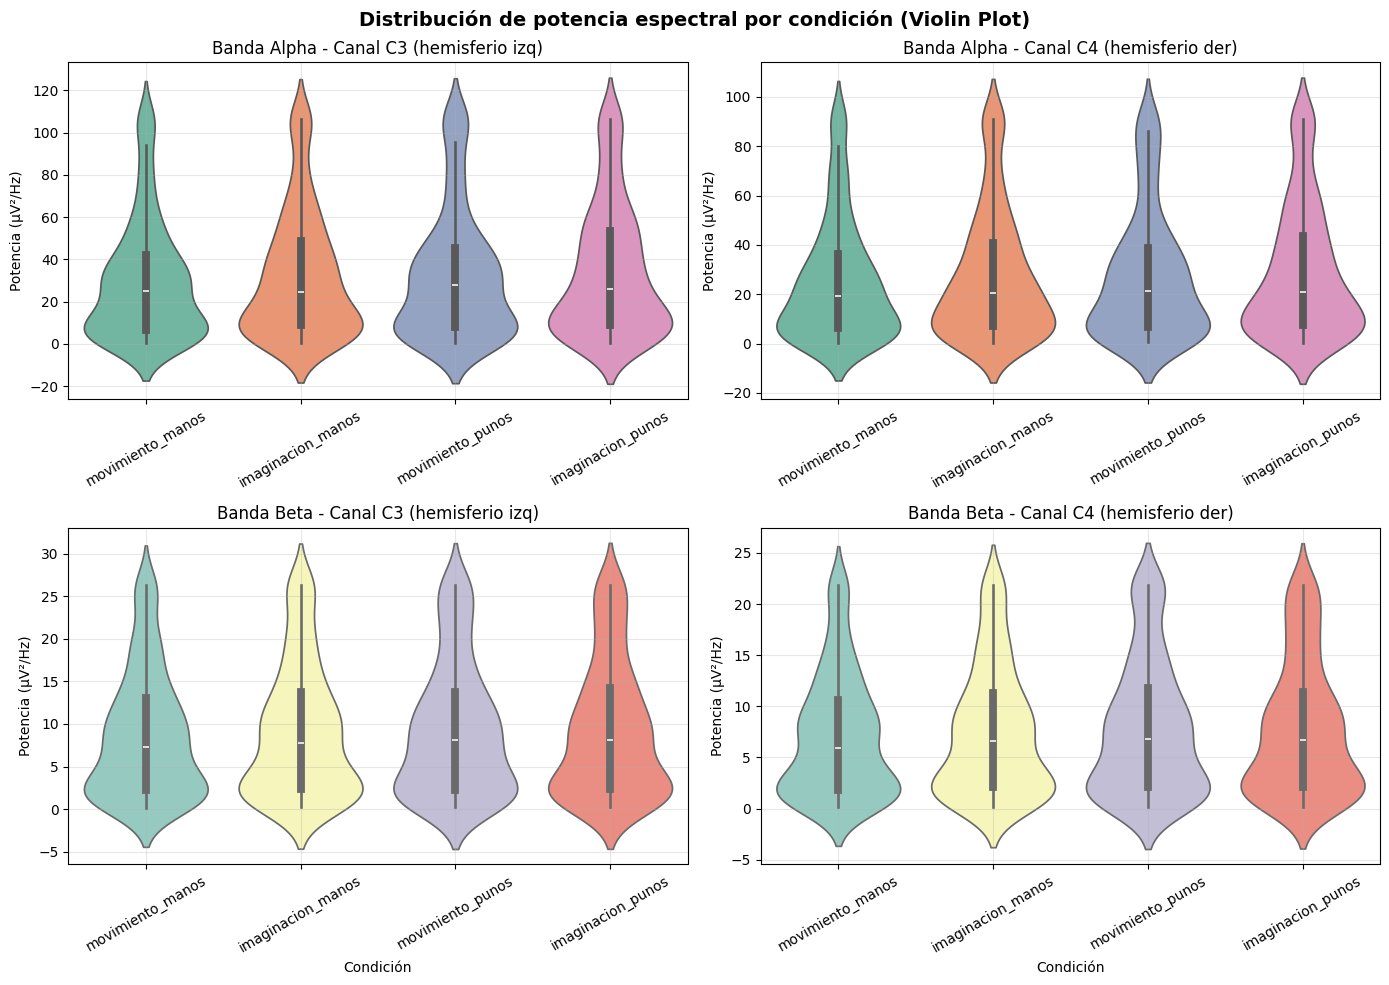

Figura guardada como 'violinplot_alpha_beta.png'


In [67]:
# Violin plot - Alpha y Beta por condición

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de potencia espectral por condición (Violin Plot)', 
             fontsize=14, fontweight='bold')

# Alpha C3
sns.violinplot(data=df_analisis, x='condicion',
               y='tarea_alpha_C3..', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Banda Alpha - Canal C3 (hemisferio izq)')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Potencia (µV²/Hz)')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(True, alpha=0.3)

# Alpha C4
sns.violinplot(data=df_analisis, x='condicion',
               y='tarea_alpha_C4..', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Banda Alpha - Canal C4 (hemisferio der)')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Potencia (µV²/Hz)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].grid(True, alpha=0.3)

# Beta C3
sns.violinplot(data=df_analisis, x='condicion',
               y='tarea_beta_C3..', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Banda Beta - Canal C3 (hemisferio izq)')
axes[1,0].set_xlabel('Condición')
axes[1,0].set_ylabel('Potencia (µV²/Hz)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(True, alpha=0.3)

# Beta C4
sns.violinplot(data=df_analisis, x='condicion',
               y='tarea_beta_C4..', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Banda Beta - Canal C4 (hemisferio der)')
axes[1,1].set_xlabel('Condición')
axes[1,1].set_ylabel('Potencia (µV²/Hz)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('violinplot_alpha_beta.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'violinplot_alpha_beta.png'")

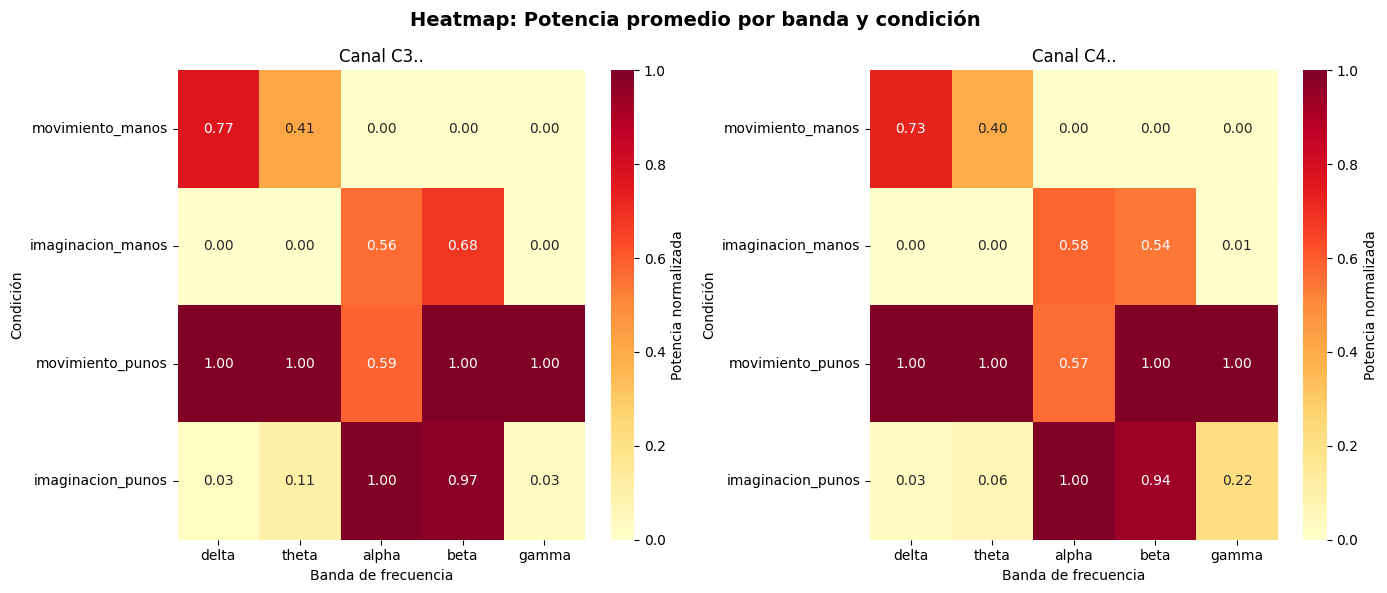

Figura guardada como 'heatmap_bandas_condiciones.png'


In [68]:
# Potencia promedio por banda y condición

# Calcular potencia promedio por condición y banda para C3 y C4
condiciones = ['movimiento_manos', 'imaginacion_manos', 
               'movimiento_punos', 'imaginacion_punos']

# Crear matrices para el heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heatmap: Potencia promedio por banda y condición', 
             fontsize=14, fontweight='bold')

for ax, canal in zip(axes, ['C3..', 'C4..']):
    # Construir matriz: filas=condiciones, columnas=bandas
    matriz = []
    for cond in condiciones:
        fila = []
        for banda in BANDAS.keys():
            col = f'tarea_{banda}_{canal}'
            valor = df_analisis[df_analisis['condicion'] == cond][col].mean()
            fila.append(valor)
        matriz.append(fila)
    
    matriz = np.array(matriz)
    
    # Normalizar por fila para ver patrones relativos
    matriz_norm = (matriz - matriz.min(axis=0)) / (matriz.max(axis=0) - matriz.min(axis=0))
    
    sns.heatmap(
        matriz_norm,
        ax=ax,
        xticklabels=list(BANDAS.keys()),
        yticklabels=condiciones,
        cmap='YlOrRd',
        annot=True,
        fmt='.2f',
        cbar_kws={'label': 'Potencia normalizada'}
    )
    ax.set_title(f'Canal {canal}')
    ax.set_xlabel('Banda de frecuencia')
    ax.set_ylabel('Condición')

plt.tight_layout()
plt.savefig('heatmap_bandas_condiciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'heatmap_bandas_condiciones.png'")


In [69]:
# Prueba de normalidad - Shapiro-Wilk

from scipy.stats import shapiro

print("=== PRUEBA DE NORMALIDAD SHAPIRO-WILK ===\n")
print("H₀: Los datos siguen una distribución normal")
print("H₁: Los datos NO siguen una distribución normal")
print("Nivel de significancia: α = 0.05\n")

bandas_interes = ['alpha', 'beta']
canales_interes = ['C3..', 'C4..']

# Incluir reposo para hipótesis 1
todas_condiciones = ['reposo', 'movimiento_manos', 'imaginacion_manos', 
                     'movimiento_punos', 'imaginacion_punos']

resultados_normalidad = {}

for banda in bandas_interes:
    for canal in canales_interes:
        print(f"--- {banda.upper()} - {canal} ---")
        for cond in todas_condiciones:
            # Para reposo usamos T0 (no tarea)
            if cond == 'reposo':
                col = f'reposo_{banda}_{canal}'
            else:
                col = f'tarea_{banda}_{canal}'
            
            datos = df[df['condicion'] == cond][col].dropna()
            if len(datos) < 3:
                continue
            stat, p = shapiro(datos[:50])
            normal = "Normal" if p > 0.05 else "No normal"
            print(f"   {cond}: p = {p:.4f} → {normal}")
            resultados_normalidad[f"{banda}_{canal}_{cond}"] = p
        print()

=== PRUEBA DE NORMALIDAD SHAPIRO-WILK ===

H₀: Los datos siguen una distribución normal
H₁: Los datos NO siguen una distribución normal
Nivel de significancia: α = 0.05

--- ALPHA - C3.. ---
   reposo: p = 0.0000 → No normal
   movimiento_manos: p = 0.0008 → No normal
   imaginacion_manos: p = 0.0013 → No normal
   movimiento_punos: p = 0.0011 → No normal
   imaginacion_punos: p = 0.0006 → No normal

--- ALPHA - C4.. ---
   reposo: p = 0.0000 → No normal
   movimiento_manos: p = 0.0016 → No normal
   imaginacion_manos: p = 0.0021 → No normal
   movimiento_punos: p = 0.0000 → No normal
   imaginacion_punos: p = 0.0006 → No normal

--- BETA - C3.. ---
   reposo: p = 0.0000 → No normal
   movimiento_manos: p = 0.0000 → No normal
   imaginacion_manos: p = 0.0000 → No normal
   movimiento_punos: p = 0.0000 → No normal
   imaginacion_punos: p = 0.0000 → No normal

--- BETA - C4.. ---
   reposo: p = 0.0000 → No normal
   movimiento_manos: p = 0.0000 → No normal
   imaginacion_manos: p = 0.000

In [70]:
# Pruebas de hipótesis

from scipy.stats import mannwhitneyu, kruskal

# --- KRUSKAL-WALLIS ---
print("=== KRUSKAL-WALLIS: Comparación entre las 4 condiciones ===")
print("H₀: No hay diferencia en potencia entre las 4 condiciones")
print("H₁: Al menos una condición es diferente")
print("α = 0.05\n")

for banda in bandas_interes:
    for canal in canales_interes:
        col = f'tarea_{banda}_{canal}'
        grupos = [df_analisis[df_analisis['condicion'] == cond][col].dropna().values 
                  for cond in condiciones]
        stat, p = kruskal(*grupos)
        sig = "Significativo" if p <= 0.05 else "No significativo"
        print(f"   {banda.upper()} - {canal}: H = {stat:.4f}, p = {p:.4f} → {sig}")

# --- HIPÓTESIS 1 ---
print("\n=== HIPÓTESIS 1: Potencia alpha/beta vs reposo ===")
print("H₀: No hay diferencia entre condiciones y reposo")
print("H₁: La potencia es menor durante tarea que en reposo (ERD)")
print("α = 0.05\n")

for banda in bandas_interes:
    for canal in canales_interes:
        col_reposo = f'reposo_{banda}_{canal}'
        col_tarea = f'tarea_{banda}_{canal}'
        print(f"--- {banda.upper()} - {canal} ---")
        datos_reposo = df[df['condicion'] == 'reposo'][col_reposo].dropna()
        for cond in ['movimiento_manos', 'imaginacion_manos']:
            datos_tarea = df_analisis[df_analisis['condicion'] == cond][col_tarea].dropna()
            stat, p = mannwhitneyu(datos_reposo, datos_tarea, alternative='two-sided')
            sig = "Significativo" if p <= 0.05 else "No significativo"
            print(f"   reposo vs {cond}: p = {p:.4f} → {sig}")
        print()

# --- HIPÓTESIS 2 ---
print("\n=== HIPÓTESIS 2: Lateralización C3 vs C4 ===")
print("H₀: No hay diferencia entre C3 y C4")
print("H₁: C3 y C4 muestran activación contralateral diferente")
print("α = 0.05\n")

for banda in bandas_interes:
    print(f"--- {banda.upper()} ---")
    for cond in ['movimiento_manos', 'imaginacion_manos']:
        col_c3 = f'tarea_{banda}_C3..'
        col_c4 = f'tarea_{banda}_C4..'
        datos_c3 = df_analisis[df_analisis['condicion'] == cond][col_c3].dropna()
        datos_c4 = df_analisis[df_analisis['condicion'] == cond][col_c4].dropna()
        stat, p = mannwhitneyu(datos_c3, datos_c4, alternative='two-sided')
        sig = "Significativo" if p <= 0.05 else "No significativo"
        print(f"   {cond} C3 vs C4: p = {p:.4f} → {sig}")
    print()

# --- HIPÓTESIS 3 ---
print("\n=== HIPÓTESIS 3: Movimiento real vs imaginado ===")
print("H₀: No hay diferencia entre movimiento real e imaginado")
print("H₁: El movimiento real produce mayor ERD que el imaginado")
print("α = 0.05\n")

for banda in bandas_interes:
    for canal in canales_interes:
        col = f'tarea_{banda}_{canal}'
        datos_real = df_analisis[df_analisis['condicion'] == 'movimiento_manos'][col].dropna()
        datos_imag = df_analisis[df_analisis['condicion'] == 'imaginacion_manos'][col].dropna()
        stat, p = mannwhitneyu(datos_real, datos_imag, alternative='two-sided')
        sig = "Significativo" if p <= 0.05 else "No significativo"
        print(f"   {banda.upper()} - {canal}: movimiento vs imaginación: p = {p:.4f} → {sig}")

=== KRUSKAL-WALLIS: Comparación entre las 4 condiciones ===
H₀: No hay diferencia en potencia entre las 4 condiciones
H₁: Al menos una condición es diferente
α = 0.05

   ALPHA - C3..: H = 3.9049, p = 0.2719 → No significativo
   ALPHA - C4..: H = 3.0823, p = 0.3791 → No significativo
   BETA - C3..: H = 1.2498, p = 0.7411 → No significativo
   BETA - C4..: H = 1.8205, p = 0.6105 → No significativo

=== HIPÓTESIS 1: Potencia alpha/beta vs reposo ===
H₀: No hay diferencia entre condiciones y reposo
H₁: La potencia es menor durante tarea que en reposo (ERD)
α = 0.05

--- ALPHA - C3.. ---
   reposo vs movimiento_manos: p = 0.0000 → Significativo
   reposo vs imaginacion_manos: p = 0.0000 → Significativo

--- ALPHA - C4.. ---
   reposo vs movimiento_manos: p = 0.0000 → Significativo
   reposo vs imaginacion_manos: p = 0.0000 → Significativo

--- BETA - C3.. ---
   reposo vs movimiento_manos: p = 0.0000 → Significativo
   reposo vs imaginacion_manos: p = 0.0000 → Significativo

--- BETA - C